In [52]:
#Import Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

#Read CSV file
df= pd.read_csv('/content/Bank_Personal_Loan_Modelling.csv')
df.head(10)



,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
5,6,37,13,29,92121,4,0.4,2,155,0,0,0,1,0
6,7,53,27,72,91711,2,1.5,2,0,0,0,0,1,0
7,8,50,24,22,93943,1,0.3,3,0,0,0,0,0,1
8,9,35,10,81,90089,3,0.6,2,104,0,0,0,1,0
9,10,34,9,180,93023,1,8.9,3,0,1,0,0,0,0


In [51]:
df.tail(10)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
4990,4991,55,25,58,95023,4,2.00,3,219,0,0,0,0,1
4991,4992,51,25,92,91330,1,1.90,2,100,0,0,0,0,1
4992,4993,30,5,13,90037,4,0.50,3,0,0,0,0,0,0
4993,4994,45,21,218,91801,2,6.67,1,0,0,0,0,1,0
4994,4995,64,40,75,94588,3,2.00,3,0,0,0,0,1,0
4995,4996,29,3,40,92697,1,1.90,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.40,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.30,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.50,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.80,1,0,0,0,0,1,1


In [54]:
df.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIP Code,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal Loan,0


In [55]:
df.shape

(5000, 14)

In [56]:
df.dtypes

,0
ID,int64
Age,int64
Experience,int64
Income,int64
ZIP Code,int64
Family,int64
CCAvg,float64
Education,int64
Mortgage,int64
Personal Loan,int64


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [60]:
df.Online.value_counts()

,count
Online,
1,2984
0,2016


In [61]:
df.CreditCard.value_counts()

,count
CreditCard,
0,3530
1,1470


In [63]:
x = df.drop('Online',axis=1)
y = df['Online']

x.shape

(5000, 13)

In [64]:
y

,Online
0,0
1,0
2,0
3,0
4,0
...,...
4995,1
4996,1
4997,0
4998,1


In [70]:
#Splitting the Data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=1)


In [71]:
#Using Logistic Regression
from sklearn.linear_model import LogisticRegression
mod = LogisticRegression()
mod.fit(x_train,y_train)
LogisticRegression()

y_pred = mod.predict(x_test)

print('train score: ', mod.score(x_train, y_train))
print('test score: ', mod.score(x_test, y_test))    #under fitting

train score:  0.5911428571428572
test score:  0.61


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Axes: >

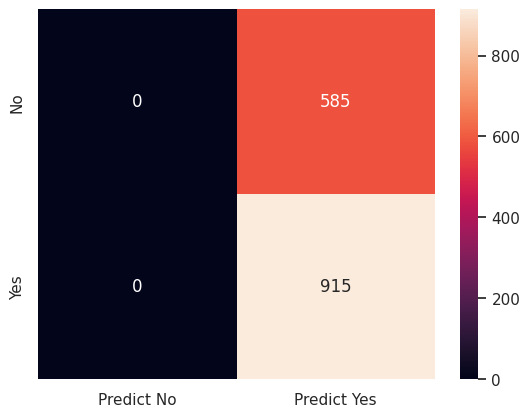

In [72]:
from sklearn import metrics
cm = metrics.confusion_matrix(y_test, y_pred,labels=[0,1])

dd = pd.DataFrame(cm, index = [i for i in ['No','Yes']], columns = [i for i in ['Predict No','Predict Yes']])
sns.heatmap(dd,annot=True,fmt='g')

There is chance of 915 people likely to buy a load from this model prediction

In [73]:
#Using K-NN

from sklearn.neighbors import KNeighborsClassifier
mod1 = KNeighborsClassifier()
mod1.fit(x_train, y_train)
KNeighborsClassifier()

print('train score: ', mod1.score(x_train, y_train))
print('test score: ', mod1.score(x_test, y_test))    #slightly overfitting

train score:  0.7014285714285714
test score:  0.556


<Axes: >

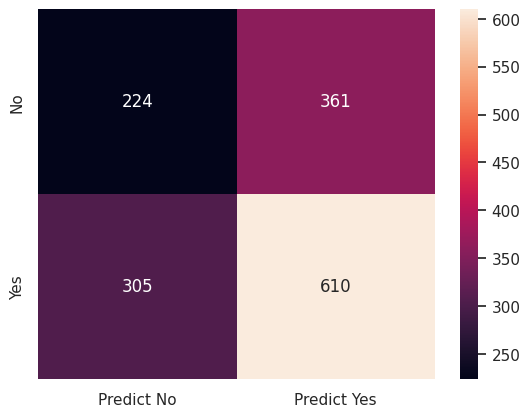

In [74]:
yp = mod1.predict(x_test)
cm1 = metrics.confusion_matrix(y_test, yp,labels=[0,1])

d1 = pd.DataFrame(cm1, index = [i for i in ['No','Yes']], columns = [i for i in ['Predict No','Predict Yes']])
sns.heatmap(d1,annot=True,fmt='g')

Likely 610 people will buy a loan from KNN Model

In [75]:
#Using Naive Bayes
from sklearn.naive_bayes import GaussianNB
m = GaussianNB()
m.fit(x_train, y_train)
GaussianNB()

print('train score: ', m.score(x_train, y_train))
print('test score: ', m.score(x_test, y_test))    #under fitting

train score:  0.46485714285714286
test score:  0.436


<Axes: >

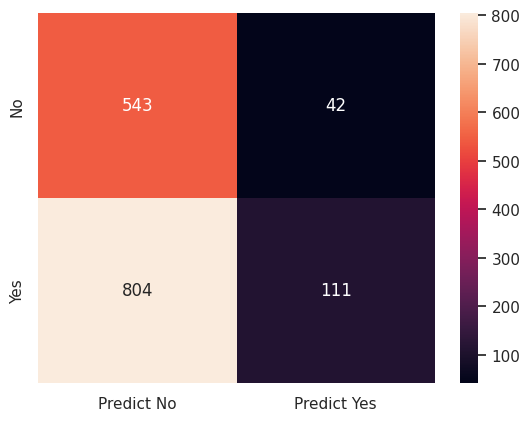

In [77]:
ypp = m.predict(x_test)
cn = metrics.confusion_matrix(y_test, ypp,labels=[0,1])

d2 = pd.DataFrame(cn, index = [i for i in ['No','Yes']], columns = [i for i in ['Predict No','Predict Yes']])
sns.heatmap(d2,annot=True,fmt='g')

We are getting worst results from Naive Bayes model


**Conclusion**

In my opinion using Logistic Regression is the best model for this banking loan problem, becaseue we are getting like 915 people bying the loan.
